In [155]:
import pandas as pd

数据来源文件读取

In [156]:
happiness = pd.read_csv("../data/happiness.csv")
income = pd.read_csv("../data/income.csv")
house = pd.read_csv("../data/house_price.csv")
province = pd.read_csv("../data/province.csv")
location = pd.read_csv("../data/location.csv")

happiness.head()

,city,happiness
0,Beijing,91.61
1,Shanghai,95.00
2,Tianjin,65.56
3,Chongqing,68.63
4,Guangzhou,82.16


数据重复性检查及处理

In [157]:
df = (
    happiness
    .merge(income, on="city")
    .merge(house, on="city")
    .merge(province, on="city")
    .merge(location, on="city")
)

duplicates = df["city"].duplicated().sum()

print(f"Duplicate cities: {duplicates}")

for name, data in {
    "happiness": happiness,
    "income": income,
    "house": house,
    "province": province,
    "longitude": location,
    "latitude": location
}.items():

    before = len(data)
    data.drop_duplicates("city", inplace=True)
    after = len(data)

    print(
        f"{name}: 删除 {before-after} 条重复数据，剩余 {after} 条"
    )

df.head()

Duplicate cities: 1581
happiness: 删除 51 条重复数据，剩余 249 条
income: 删除 51 条重复数据，剩余 249 条
house: 删除 51 条重复数据，剩余 249 条
province: 删除 51 条重复数据，剩余 249 条
longitude: 删除 51 条重复数据，剩余 249 条
latitude: 删除 0 条重复数据，剩余 249 条


,city,happiness,income,house_price,province,longitude,latitude
0,Beijing,91.61,181438,48492,北京市,116.4074,39.9042
1,Shanghai,95.00,203863,61399,上海市,121.4737,31.2304
2,Tianjin,65.56,76008,11056,天津市,117.2000,39.1333
3,Chongqing,68.63,91580,11579,重庆市,106.5516,29.5630
4,Guangzhou,82.16,138320,39415,广东省,113.2644,23.1291


数据缺失值检查及处理

In [158]:
df.isnull().sum()

print("Missing Values:")
print(df.isnull().sum())

df.dropna(inplace=True)

print("After Dropping Missing Values:")
print(df.isnull().sum())

df = (
    happiness
    .merge(income, on="city")
    .merge(house, on="city")
    .merge(province, on="city")
    .merge(location, on="city")
)

df.head()

Missing Values:
city           0
happiness      0
income         0
house_price    0
province       0
longitude      0
latitude       0
dtype: int64
After Dropping Missing Values:
city           0
happiness      0
income         0
house_price    0
province       0
longitude      0
latitude       0
dtype: int64


,city,happiness,income,house_price,province,longitude,latitude
0,Beijing,91.61,181438,48492,北京市,116.4074,39.9042
1,Shanghai,95.00,203863,61399,上海市,121.4737,31.2304
2,Tianjin,65.56,76008,11056,天津市,117.2000,39.1333
3,Chongqing,68.63,91580,11579,重庆市,106.5516,29.5630
4,Guangzhou,82.16,138320,39415,广东省,113.2644,23.1291


查看数据规模

In [159]:
print(f"数据集大小：{df.shape[0]} 行 × {df.shape[1]} 列")

df.head()

数据集大小：249 行 × 7 列


,city,happiness,income,house_price,province,longitude,latitude
0,Beijing,91.61,181438,48492,北京市,116.4074,39.9042
1,Shanghai,95.00,203863,61399,上海市,121.4737,31.2304
2,Tianjin,65.56,76008,11056,天津市,117.2000,39.1333
3,Chongqing,68.63,91580,11579,重庆市,106.5516,29.5630
4,Guangzhou,82.16,138320,39415,广东省,113.2644,23.1291


显示数据类型

In [160]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   city         249 non-null    str    
 1   happiness    249 non-null    float64
 2   income       249 non-null    int64  
 3   house_price  249 non-null    int64  
 4   province     249 non-null    str    
 5   longitude    249 non-null    float64
 6   latitude     249 non-null    float64
dtypes: float64(3), int64(2), str(2)
memory usage: 18.0 KB


数据描述统计

In [161]:
df.describe().round(2)

,happiness,income,house_price,longitude,latitude
count,249.00,249.00,249.00,249.00,249.00
mean,70.68,90744.53,14536.25,113.39,32.34
std,5.62,20257.04,13451.77,7.34,6.58
min,56.83,9800.00,7553.00,86.73,19.67
25%,67.14,80672.00,10948.00,108.94,27.63
50%,70.18,90285.00,12044.00,113.82,31.29
75%,72.78,97835.00,13536.00,117.97,37.10
max,95.00,203863.00,165000.00,126.90,46.62


一开始没有province.csv和location.csv,所以我直接在这儿用了一堆映射,但后来我在做geo地图时发现总这么映射太笨重了,徒费心力

性价比指标计算和各省市数据平均值的聚合与重命名

In [162]:
import numpy as np

# 计算性价比指标
df['value_index'] = df['income'] / df['house_price']

# 按省份聚合平均值
province_summary = df.groupby('province', as_index=False).agg({
    'happiness': 'mean',
    'income': 'mean',
    'house_price': 'mean',
    'value_index': 'mean'
})
# 重命名列为平均值
province_summary = province_summary.rename(columns={
    'happiness': 'avg_happiness',
    'income': 'avg_income',
    'house_price': 'avg_house_price',
    'value_index': 'avg_value_index'
})
print("\n省级聚合样例：\n", province_summary.head(5), sep="")


省级聚合样例：
  province  avg_happiness     avg_income  avg_house_price  avg_value_index
0      上海市      95.000000  203863.000000     61399.000000         3.320298
1      云南省      69.970909   89588.909091     11387.909091         8.290937
2   内蒙古自治区      68.761429   95754.571429     12700.428571         7.592269
3      北京市      91.610000  181438.000000     48492.000000         3.741607
4      台湾省      81.800000   18500.000000     42000.000000         0.440476


住房可负担性指数排名前20的城市的数据显示

In [163]:
import pandas as pd

# 取 Top20
top20 = (
    df.sort_values("value_index", ascending=False)
      .head(20)
      .reset_index(drop=True)
)

top20

,city,happiness,income,house_price,province,longitude,latitude,value_index
0,Lijiang,70.49,104552,7553,云南省,103.4669,25.4659,13.842447
1,Zhangzhou,69.04,103668,7969,福建省,118.8747,26.8599,13.008910
2,Baicheng,70.60,103389,8110,吉林省,125.3567,44.6249,12.748335
3,Songyuan,68.94,106003,9179,吉林省,126.0722,44.0520,11.548426
4,Yangzhou,64.37,100401,8917,江苏省,118.5513,32.7668,11.259504
5,Putian,75.60,88638,8228,福建省,120.4953,25.5879,10.772727
6,Jinan,73.70,91385,8763,山东省,117.1201,36.6512,10.428506
7,Fuzhou Jiangxi,74.86,101173,9757,江西省,116.6812,28.9528,10.369273
8,Deyang,70.89,95243,9195,四川省,105.1273,30.2580,10.358129
9,Liaocheng,75.73,93414,9058,山东省,115.8028,37.6386,10.312873


全国300个主要城市的住房可负担性指数的柱状图分布分析

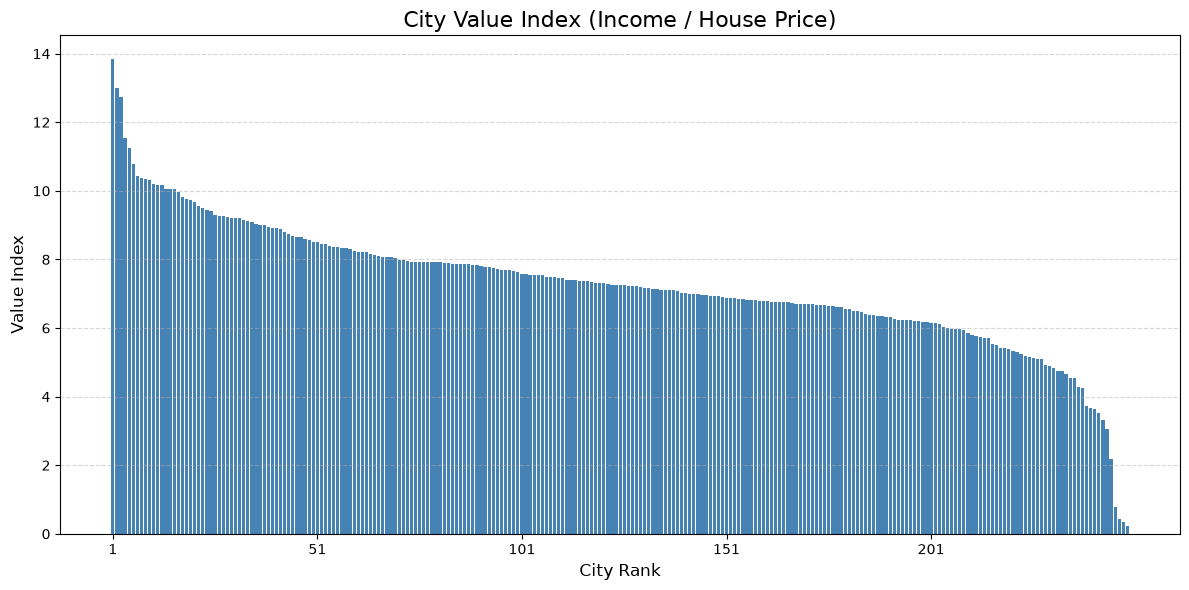

In [164]:
import matplotlib.pyplot as plt
import numpy as np
#按价值指数降序排序
top = df.sort_values("value_index", ascending=False).reset_index(drop=True)
#创建画布
fig, ax = plt.subplots(figsize=(12, 6))
#绘制柱状图
ax.bar(range(len(top)), top["value_index"], color="steelblue")
#每50个城市显示一个排名
step = 50
ticks = np.arange(0, len(top), step)

ax.set_xticks(ticks)
ax.set_xticklabels([str(i + 1) for i in ticks])
#设置标题和坐标轴标签
ax.set_title("City Value Index (Income / House Price)", fontsize=16)
ax.set_xlabel("City Rank", fontsize=12)
ax.set_ylabel("Value Index", fontsize=12)
#添加横向网格线
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

全国300个主要城市的幸福度的条形图分布分析

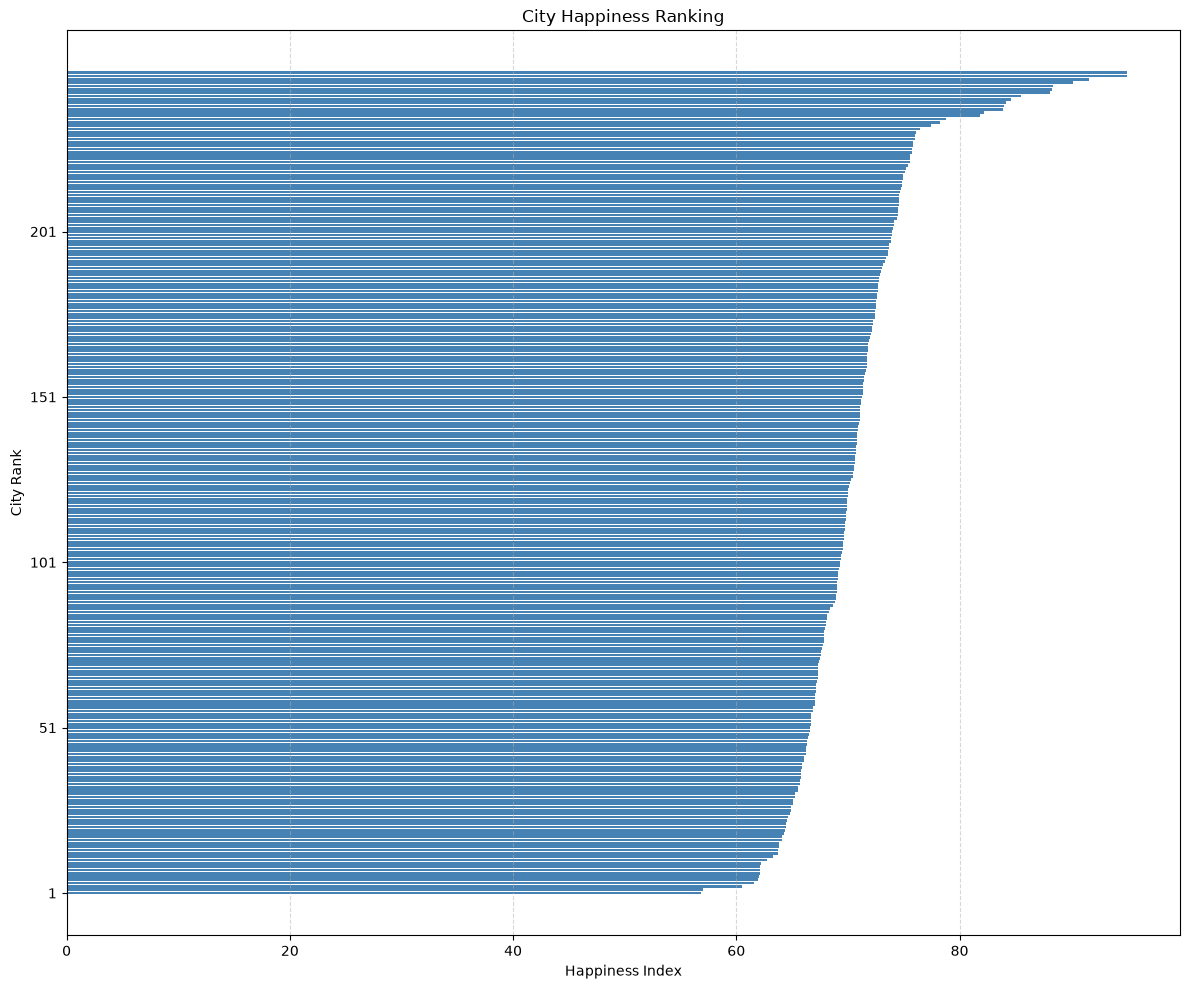

In [165]:
import matplotlib.pyplot as plt
#按幸福度排序
df_sorted = df.sort_values("happiness").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 10))

ax.barh(range(len(df_sorted)), df_sorted["happiness"], color="steelblue")
#每50个城市显示一个刻度
step = 50
ticks = list(range(0, len(df_sorted), step))
ax.set_yticks(ticks)
ax.set_yticklabels([str(i + 1) for i in ticks])

ax.set_xlabel("Happiness Index")
ax.set_ylabel("City Rank")
ax.set_title("City Happiness Ranking")
ax.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

全国300个主要城市的收入与幸福度之间的散点图分布分析

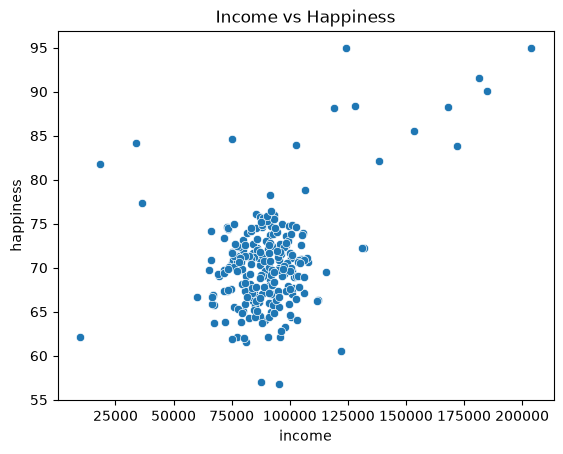

In [166]:
import seaborn as sns

sns.scatterplot(data=df, x="income", y="happiness")
plt.title("Income vs Happiness")
plt.show()

全国300个主要城市的房价与幸福度之间的散点图分布分析

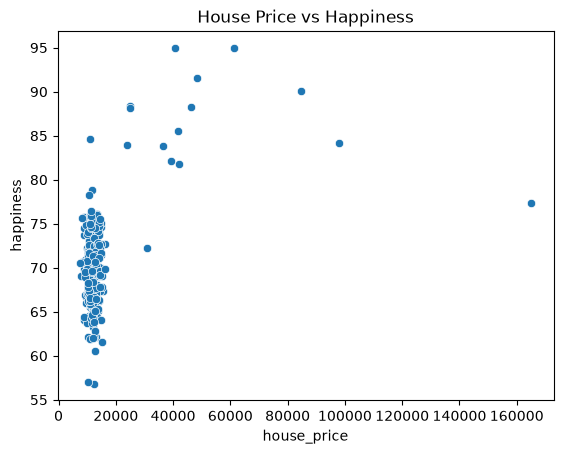

In [167]:
sns.scatterplot(data=df, x="house_price", y="happiness")
plt.title("House Price vs Happiness")
plt.show()

中国城市生活成本与幸福感分析的可视化宜居度map地图

In [168]:
from pyecharts.charts import Map
from pyecharts import options as opts

# 按省份计算平均宜居度
prov_data = df.groupby('province')['happiness'].mean().reset_index()
# 生成地图数据项列表
map_data = list(zip(prov_data['province'], prov_data['happiness']))

# 创建 Map 实例并添加数据
m = Map()
m.add("宜居度", map_data, "china")

# 配置全局选项：标题和视觉映射组件（分段）
m.set_global_opts(
    title_opts=opts.TitleOpts(title="中国各省市宜居度地图"),
    visualmap_opts=opts.VisualMapOpts(
        min_=prov_data['happiness'].min(),
        max_=prov_data['happiness'].max(),
        is_piecewise=True,  # 分段式视觉映射
        pieces=[
            {"min": 90, "label": "极高"},
            {"min": 80, "max": 90, "label": "较高"},
            {"min": 70, "max": 80, "label": "中等"},
            {"max": 70, "label": "较低"},
        ]
    ),

    tooltip_opts=opts.TooltipOpts(formatter="省市:{b}<br>宜居度:{c}")
)
# 不显示地图上每个省的标签
m.set_series_opts(label_opts=opts.LabelOpts(is_show=False))
# 渲染HTML文件
m.render("中国各省市宜居度地图.html")


'c:\\Users\\86132\\Desktop\\中国城市生活成本与幸福感分析可视化\\notebooks\\中国各省市宜居度地图.html'

Top50的中国各城市住房可负担性指数分布Geo地图

In [169]:
from pyecharts.charts import Geo
from pyecharts import options as opts
from pyecharts.globals import ChartType

geo = Geo()

# 添加地图
geo.add_schema(
    maptype="china"
)

# Top50城市
top50 = (
    df.sort_values(
        "value_index",
        ascending=False
    )
    .head(50)
)

# 读取城市坐标
for _, row in top50.iterrows():
    geo.add_coordinate(
        row["city"],
        row["longitude"],
        row["latitude"]
    )

# 构造绘图数据
geo_data = []

for _, row in top50.iterrows():
    geo_data.append(
        (
            row["city"],
            float(row["value_index"])
        )
    )

print("气泡数量:", len(geo_data))

# 添加散点
geo.add(
    "城市价值指数",
    geo_data,
    type_=ChartType.EFFECT_SCATTER,
    symbol_size=15
)

# 全局设置
geo.set_global_opts(
    title_opts=opts.TitleOpts(
        title="Top50的中国城市生活价值指数分布"
    ),
    visualmap_opts=opts.VisualMapOpts(
        min_=top50["value_index"].min(),
        max_=top50["value_index"].max(),
        is_piecewise=True,  # 分段式视觉映射
        pieces=[
            {"min": 13, "label": "极高"},
            {"min": 12, "max": 13, "label": "较高"},
            {"min": 11, "max": 12, "label": "中等"},
            {"max": 11, "label": "较低"},
        ]
    )
)

# 标签设置
geo.set_series_opts(
    label_opts=opts.LabelOpts(
        is_show=False
    )
)

geo.render(
    "Top50的中国城市生活价值指数分布.html"
)

气泡数量: 50


'c:\\Users\\86132\\Desktop\\中国城市生活成本与幸福感分析可视化\\notebooks\\Top50的中国城市生活价值指数分布.html'